IMPORTS

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

%matplotlib inline

LOAD TITANIC DATASET

In [31]:
df = sns.load_dataset("titanic")

SAVE REQUIRED OFFLINE FALLBACK

In [32]:
df.to_csv("titanic.csv", index=False)

PROFILING

In [33]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [34]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None


In [35]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [36]:
df.shape

(891, 15)

In [37]:
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


MISSING PERCENTAGES

In [39]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

print(missing_summary)

             missing_count  missing_percentage
deck                   688           77.216611
age                    177           19.865320
embarked                 2            0.224467
embark_town              2            0.224467


In [40]:
missing_percentages = df.isnull().mean() * 100

for column, percentage in missing_percentages.items():
    if percentage > 0:
        print(f"{column}: {percentage:.2f}% missing")

age: 19.87% missing
embarked: 0.22% missing
deck: 77.22% missing
embark_town: 0.22% missing


MISSING VALUE HANDLING

In [41]:
# Make a copy before cleaning
df_clean = df.copy()

# Drop rows for columns with less than 5% missing
df_clean = df_clean.dropna(subset=["embarked"])

# Impute age because its missing percentage is between 5% and 30%
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# Drop deck because its missing percentage is very high
df_clean = df_clean.drop(columns=["deck"])

print("Cleaned shape:", df_clean.shape)
print("\nRemaining missing values:")
print(df_clean.isnull().sum())

Cleaned shape: (889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


The `embarked` column had 0.22% % missing values. Because this is below
the 5% threshold, rows with missing `embarked` values were removed.

The `age` column had 19.87%% missing values. Because this falls between
5% and 30%, missing ages were imputed using the median age.

The `deck` column had 77.22% missing values. Its missingness was too high
for reliable imputation, so the column was dropped rather than creating
a large number of uncertain values.

`embark_town` was removed because it duplicates the information contained
in `embarked`.


CLASS BALANCE

In [42]:
class_counts = df_clean["survived"].value_counts()
class_percentages = df_clean["survived"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

Class counts:
survived
0    549
1    340
Name: count, dtype: int64

Class percentages:
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


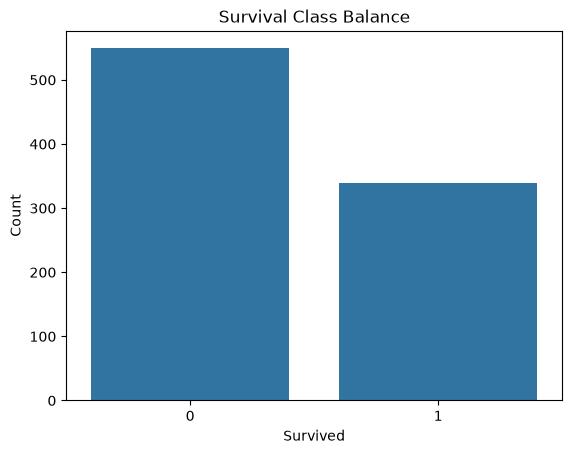

In [43]:
sns.countplot(data=df_clean, x="survived")

plt.title("Survival Class Balance")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

AGE HISTOGRAM

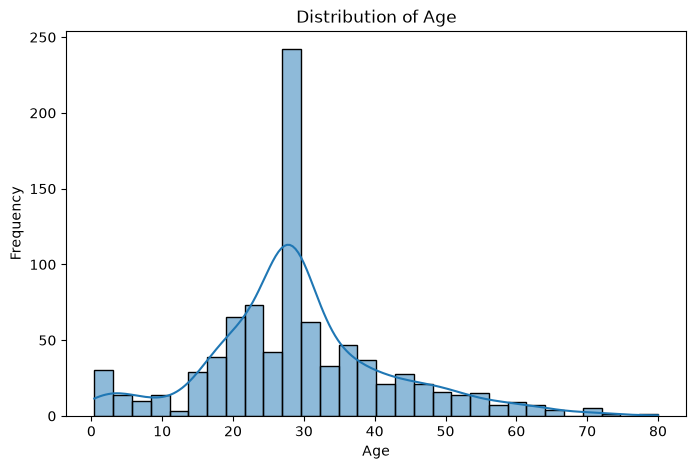

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["age"], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

AGE BOXPLOT

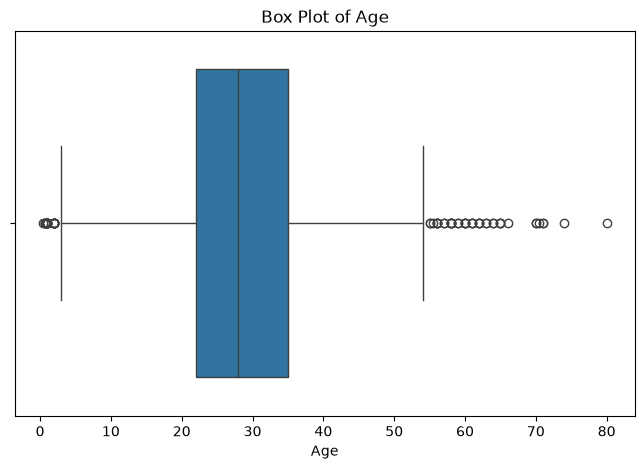

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

FARE HISTOGRAM

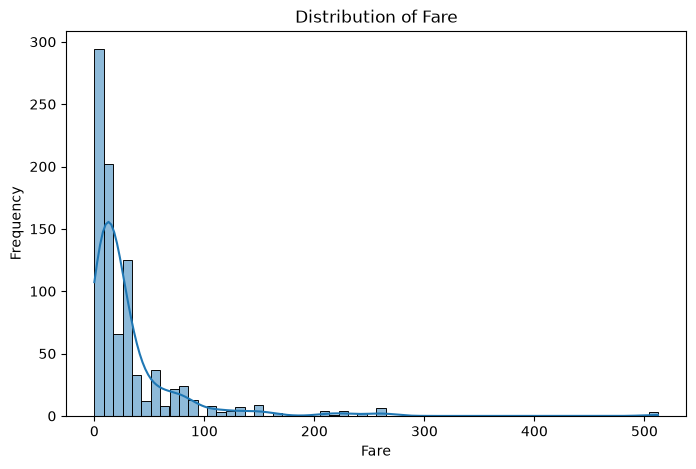

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["fare"], kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

FARE BOXPLOT

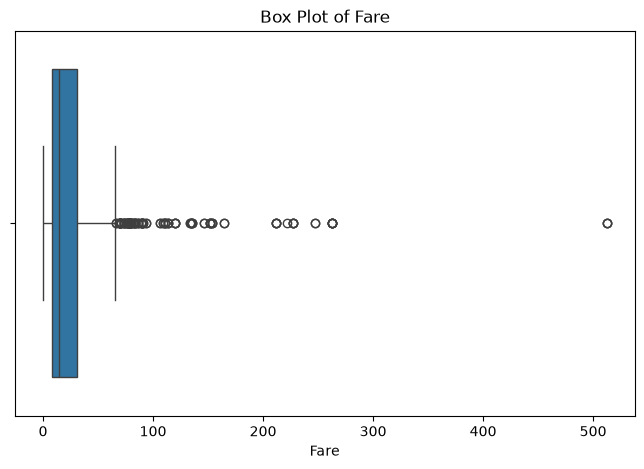

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

IQR outliers

In [48]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]
    
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    }

age_outliers = iqr_outlier_count(df_clean["age"])
fare_outliers = iqr_outlier_count(df_clean["fare"])

print("AGE")
print(age_outliers)

print("\nFARE")
print(fare_outliers)

AGE
{'Q1': np.float64(22.0), 'Q3': np.float64(35.0), 'IQR': np.float64(13.0), 'lower_bound': np.float64(2.5), 'upper_bound': np.float64(54.5), 'outlier_count': 65}

FARE
{'Q1': np.float64(7.8958), 'Q3': np.float64(31.0), 'IQR': np.float64(23.1042), 'lower_bound': np.float64(-26.7605), 'upper_bound': np.float64(65.6563), 'outlier_count': 114}


FARE STATISTICS

In [49]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode().iloc[0]

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode)

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05


In [50]:
fare_skewness = df_clean["fare"].skew()

print("Fare skewness:", fare_skewness)

Fare skewness: 4.801440211044194


Interpretation:
Fare is right-skewed because the mean is greater than the median, which is greater than the mode. This ordering indicates that relatively high fares extend the upper tail of the distribution.

SURVIVAL BY SEX

In [51]:
male_survival = (
    df_clean[df_clean["sex"] == "male"]["survived"].mean()
)

female_survival = (
    df_clean[df_clean["sex"] == "female"]["survived"].mean()
)

print("Male survival rate:", male_survival)
print("Female survival rate:", female_survival)

Male survival rate: 0.18890814558058924
Female survival rate: 0.7403846153846154


In [52]:
sex_survival = df_clean.groupby("sex")["survived"].mean()

print(sex_survival)

sex
female    0.740385
male      0.188908
Name: survived, dtype: float64


SURVIVAL BY PCLASS

In [53]:
for pclass in sorted(df_clean["pclass"].unique()):
    rate = df_clean[
        df_clean["pclass"] == pclass
    ]["survived"].mean()
    
    print(f"Pclass {pclass} survival rate: {rate:.4f}")

Pclass 1 survival rate: 0.6262
Pclass 2 survival rate: 0.4728
Pclass 3 survival rate: 0.2424


SEX + PCLASS

In [54]:
sex_pclass = (
    df_clean
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

display(sex_pclass)

,sex,pclass,survived
0,female,1,0.967391
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447


In [55]:
female_first = df_clean[
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 1)
]

print(
    "Female + First Class survival rate:",
    female_first["survived"].mean()
)

Female + First Class survival rate: 0.967391304347826


In [56]:
female_or_first = df_clean[
    (df_clean["sex"] == "female") |
    (df_clean["pclass"] == 1)
]

print(
    "Female OR First Class survival rate:",
    female_or_first["survived"].mean()
)

Female OR First Class survival rate: 0.6359447004608295


EXACT CORRELATION MATRIX

In [57]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[corr_columns].corr()

display(corr_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


CORRELATION HEATMAP

FileNotFoundError: [Errno 2] No such file or directory: 'charts/correlation_heatmap.png'

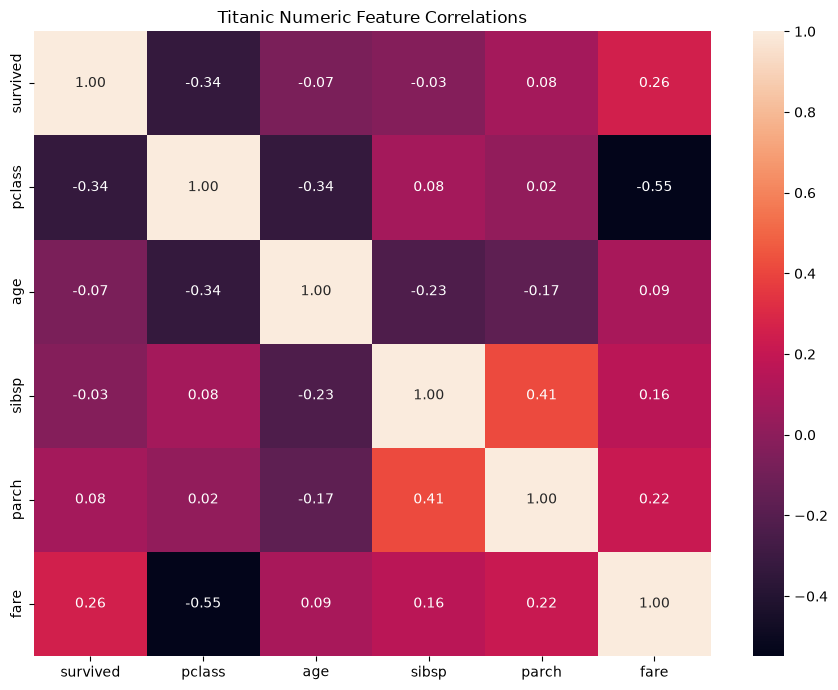

In [58]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Titanic Numeric Feature Correlations")
plt.tight_layout()

plt.savefig(
    "charts/correlation_heatmap.png",
    dpi=150
)

plt.show()

FIND STRONGEST TWO CORRELATIONS

In [59]:
correlation_pairs = []

for i in range(len(corr_columns)):
    for j in range(i + 1, len(corr_columns)):
        
        feature_1 = corr_columns[i]
        feature_2 = corr_columns[j]
        
        correlation = corr_matrix.loc[
            feature_1,
            feature_2
        ]
        
        correlation_pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "correlation": correlation,
            "absolute_correlation": abs(correlation)
        })

correlation_pairs_df = pd.DataFrame(
    correlation_pairs
).sort_values(
    "absolute_correlation",
    ascending=False
)

display(correlation_pairs_df.head(2))

,feature_1,feature_2,correlation,absolute_correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


FileNotFoundError: [Errno 2] No such file or directory: 'charts/survival_by_sex.png'

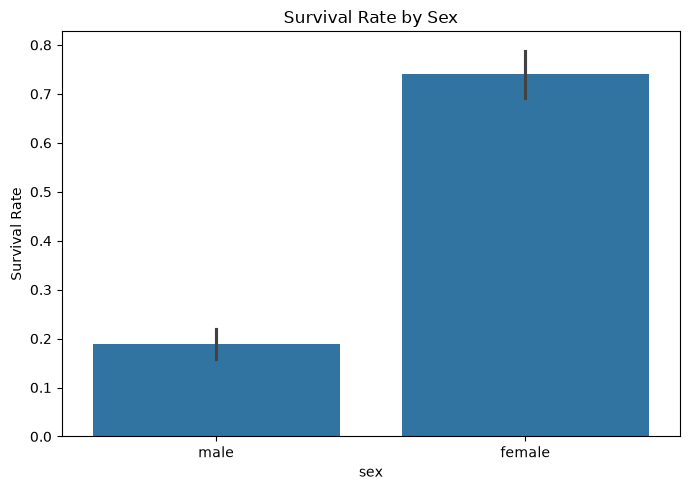

In [60]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_by_sex.png", dpi=150)
plt.show()

Interpretation

Survival differed substantially by sex. Female passengers had a much higher survival rate than male passengers, showing that sex was strongly associated with the outcome.

FileNotFoundError: [Errno 2] No such file or directory: 'charts/survival_by_sex_pclass.png'

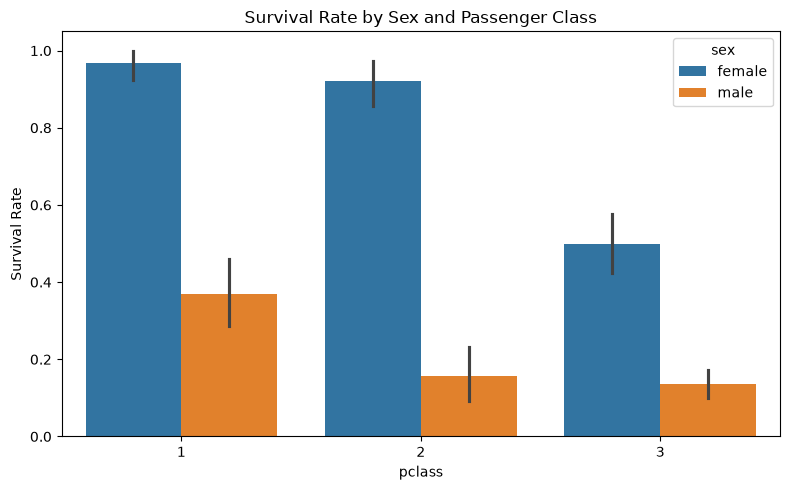

In [61]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_by_sex_pclass.png", dpi=150)
plt.show()

Interpretation

Survival rates varied considerably across passenger classes. First-class passengers generally had the highest survival rate, while third-class passengers had the lowest, indicating an association between passenger class and survival.

FileNotFoundError: [Errno 2] No such file or directory: 'charts/age_by_survival.png'

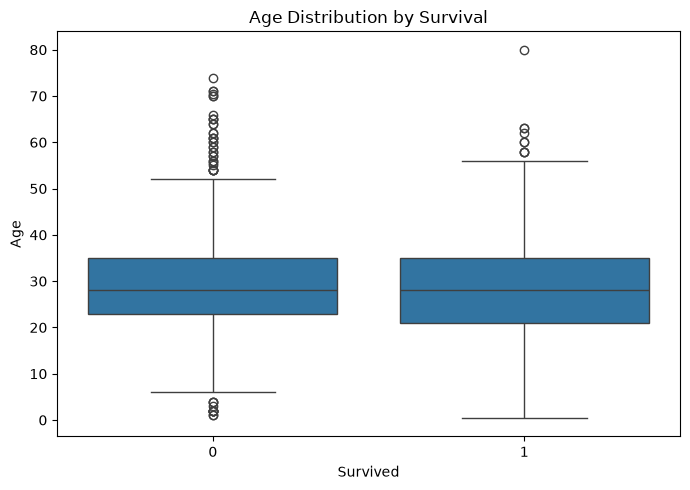

In [62]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.tight_layout()
plt.savefig("charts/age_by_survival.png", dpi=150)
plt.show()

Interpretation

Combining sex and passenger class provides a clearer survival story than either variable alone. Female passengers generally had higher survival rates within each class, while higher-class passengers also tended to have better outcomes.

FileNotFoundError: [Errno 2] No such file or directory: 'charts/age_by_survival.png'

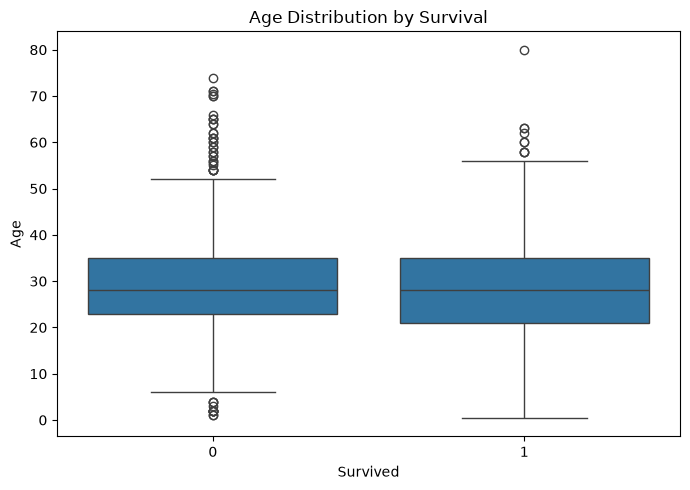

In [63]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.tight_layout()
plt.savefig(
    "charts/age_by_survival.png",
    dpi=150
)

plt.show()

Interpretation

Age distributions overlap between survivors and non-survivors, indicating that age alone does not explain survival. Nevertheless, differences in the distributions suggest that age contains useful predictive information when combined with other features.

STANDARDIZATION

In [64]:
from sklearn.preprocessing import StandardScaler

eda_scaler = StandardScaler()

df_eda_scaled = df_clean.copy()

df_eda_scaled[
    ["age_z", "fare_z"]
] = eda_scaler.fit_transform(
    df_clean[["age", "fare"]]
)

print("BEFORE")
display(
    df_clean[["age", "fare"]].agg(["mean", "std"])
)

print("\nAFTER")
display(
    
    df_eda_scaled[["age_z", "fare_z"]].agg(["mean", "std"])
)

BEFORE


,age,fare
mean,29.315152,32.096681
std,12.984932,49.697504



AFTER


,age_z,fare_z
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00


Interpretation:

After standardization, both age_z and fare_z have means approximately equal to 0 and standard deviations approximately equal to 1. This confirms that the z-score transformation was applied correctly. These EDA-standardized columns are not used in the modeling pipeline.